# OlmoEarth v1.1: a small runnable demo

On May 19, 2026, Ai2 released [OlmoEarth v1.1](https://huggingface.co/blog/allenai/olmoearth-v1-1) — a minor-version refresh of the OlmoEarth Earth observation foundation model family they first shipped in November 2025. This post is a short, runnable explainer:

- what OlmoEarth v1.1 actually changes,
- how to load the smallest model on a laptop in ~1 second,
- one simple application: embedding synthetic Sentinel-2 chips and doing nearest-neighbour land-cover classification.

No GPU, no API keys, no Sentinel-2 download. Synthetic chips with realistic per-band reflectance statistics are enough to show the embeddings are doing something.

## What v1.1 changes

OlmoEarth v1 was a vision transformer pre-trained on ~10 TB of multimodal Earth observation data globally resampled to 10 m/pixel, with up to 12 monthly timesteps per sample. It ingests Sentinel-2, Sentinel-1, and Landsat as satellite modalities, plus map products (OpenStreetMap, ESA WorldCover, USDA Cropland Data Layer, SRTM DEM, WRI Canopy Height, WorldCereal) as weak supervision.

Four sizes: Nano (~1.4 M), Tiny (~6.2 M), Base (~90 M), Large (~300 M). The Base model already beat DINOv3, Prithvi (NASA/IBM), and AlphaEarth Foundations (Google DeepMind) on the OlmoEarth-Bench k-NN and linear-probe protocols.

**The v1.1 delta is purely methodological:** same data, smarter tokeniser.

- v1 emitted **6 tokens per spatial patch per timestep** for Sentinel-2 (one per resolution group of bands).
- v1.1 emits **2 tokens per spatial patch per timestep** by merging resolution groups into a single token after a small per-resolution projection.
- Naive merging causes a ~10 percentage-point drop on downstream tasks. The fix is a modified pre-training objective that explicitly stabilises the merged token.
- Net effect: **~3× cheaper inference and shorter sequences**, same downstream quality.

On a country-scale crop map of India, the difference between 6 tokens and 2 tokens per patch is the difference between a job that fits on one node overnight and one that doesn't.

## Install

The official package is `olmoearth-pretrain`. The inference-only path doesn't need `olmo-core`.

In [1]:
# !pip install --quiet olmoearth-pretrain

In [2]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt

from olmoearth_pretrain.model_loader import load_model_from_id, ModelID
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue

torch.manual_seed(0)
np.random.seed(0)
print("torch:", torch.__version__)

torch: 2.7.1


## Load OlmoEarth-v1-Nano

Nano is ~3.5 M parameters in the published checkpoint. On a MacBook this loads in about a second after the first download caches the weights in `~/.cache/huggingface/`.

In [3]:
t0 = time.time()
model = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"loaded in {time.time() - t0:.1f}s")
print(f"parameters: {n_params/1e6:.2f} M")

loaded in 1.3s
parameters: 3.55 M


## Synthetic Sentinel-2 chips with realistic per-band statistics

OlmoEarth's Sentinel-2 L2A input has 12 bands in this order:

`B02, B03, B04, B08, B05, B06, B07, B8A, B11, B12, B01, B09`

Instead of pulling a real Sentinel-2 scene, we synthesise three small *classes* of 128×128 chip by sampling Gaussian noise around literature-typical per-band reflectance vectors:

- **water**: very low NIR/SWIR, modest visible blue/green,
- **forest**: high NIR (B08, B8A), high red-edge (B05-B07), low visible red,
- **urban**: flat-ish across the spectrum, high SWIR (B11, B12).

If OlmoEarth's representation is sensible, the embeddings of these chips should cluster by class. That is exactly what a real downstream user is hoping for when they reach for a frozen encoder.

In [4]:
# Order matches SENTINEL2_L2A band_sets in olmoearth_pretrain.
# 10 m: B02, B03, B04, B08    20 m: B05, B06, B07, B8A, B11, B12    60 m: B01, B09
BAND_NAMES = ["B02", "B03", "B04", "B08", "B05", "B06", "B07", "B8A", "B11", "B12", "B01", "B09"]

MEAN_BY_CLASS = {
    "water":  np.array([0.08, 0.07, 0.05, 0.02, 0.04, 0.02, 0.02, 0.02, 0.01, 0.01, 0.10, 0.05]),
    "forest": np.array([0.04, 0.06, 0.04, 0.35, 0.10, 0.25, 0.30, 0.35, 0.20, 0.10, 0.06, 0.03]),
    "urban":  np.array([0.12, 0.13, 0.15, 0.18, 0.14, 0.18, 0.20, 0.20, 0.25, 0.22, 0.15, 0.07]),
}
CLASSES = list(MEAN_BY_CLASS.keys())

def make_chip(cls: str, h: int = 128, w: int = 128, noise: float = 0.02) -> np.ndarray:
    mean = MEAN_BY_CLASS[cls]
    chip = mean[None, None, :] + np.random.randn(h, w, 12) * noise
    return np.clip(chip, 0, 1).astype("float32")

N_PER_CLASS = 10
labels = np.array([i for i, _ in enumerate(CLASSES) for _ in range(N_PER_CLASS)])
chips = np.stack([make_chip(CLASSES[lbl]) for lbl in labels])  # (N, H, W, 12)
print("chip batch shape:", chips.shape, "labels:", labels[:5], "...")

chip batch shape: (30, 128, 128, 12) labels: [0 0 0 0 0] ...


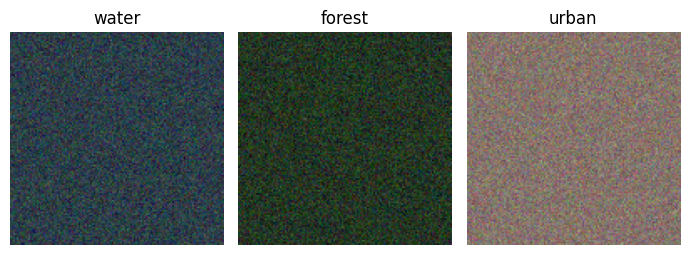

In [5]:
# Preview one chip per class as a true-colour composite (B04 red, B03 green, B02 blue).
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
for ax, cls in zip(axes, CLASSES):
    chip = make_chip(cls)
    rgb = np.stack([chip[:, :, 2], chip[:, :, 1], chip[:, :, 0]], axis=-1)  # B04, B03, B02
    rgb = np.clip(rgb * 3.5, 0, 1)  # display stretch
    ax.imshow(rgb)
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Embed the batch with OlmoEarth-v1-Nano

OlmoEarth's expected input is a `MaskedOlmoEarthSample`:

- `sentinel2_l2a`: `(B, H, W, T, num_bands=12)` reflectance in `[0, 1]`.
- `sentinel2_l2a_mask`: `(B, H, W, T, num_band_sets=3)` — one mask entry per band-set (10 m / 20 m / 60 m). We use `MaskValue.ONLINE_ENCODER` everywhere because we are doing inference, not pre-training.
- `timestamps`: `(B, T, 3)` long tensor of `[day, month_zero_indexed, year]`.
- `latlon`: `(B, 2)` float tensor.

The encoder returns two useful things:

- `tokens_and_masks.sentinel2_l2a` of shape `(B, h_patches, w_patches, T, num_band_sets, D)` — per-patch, per-band-set tokens. For Nano with `patch_size=16` and a 128×128 chip that's `(B, 8, 8, 1, 3, 128)`.
- `project_aggregated` of shape `(B, D)` — a single scene embedding per chip. This is what we'll feed to k-NN.

In [6]:
def build_masked_sample(chip_batch: np.ndarray, lat: float = 28.6, lon: float = 77.2,
                       day: int = 15, month_zero_indexed: int = 10, year: int = 2024):
    """Wrap a (B, H, W, 12) chip batch into a MaskedOlmoEarthSample."""
    B, H, W, _ = chip_batch.shape
    s2 = torch.from_numpy(chip_batch[:, :, :, None, :])  # add T=1
    s2_mask = torch.full((B, H, W, 1, 3), float(MaskValue.ONLINE_ENCODER.value))
    latlon = torch.tensor([[lat, lon]] * B).float()
    latlon_mask = torch.full((B, 2), float(MaskValue.ONLINE_ENCODER.value))
    ts = torch.tensor([[[day, month_zero_indexed, year]]] * B).long()
    return MaskedOlmoEarthSample(
        timestamps=ts,
        sentinel2_l2a=s2,
        sentinel2_l2a_mask=s2_mask,
        latlon=latlon,
        latlon_mask=latlon_mask,
    )

masked = build_masked_sample(chips)

t0 = time.time()
with torch.no_grad():
    out = model.encoder(masked, patch_size=16)
scene_emb = out["project_aggregated"].cpu().numpy()      # (N, 128)
patch_tokens = out["tokens_and_masks"].sentinel2_l2a      # (N, 8, 8, 1, 3, 128)
print(f"forward pass: {time.time() - t0:.2f}s")
print("scene embedding shape:", scene_emb.shape)
print("per-patch token shape:", tuple(patch_tokens.shape))

forward pass: 0.10s
scene embedding shape: (30, 128)
per-patch token shape: (30, 8, 8, 1, 3, 128)


## Do the embeddings cluster by class?

Project the 128-dim scene embeddings into 2D with PCA and colour by class. If OlmoEarth's representation respects spectral structure, the three clouds should separate cleanly.

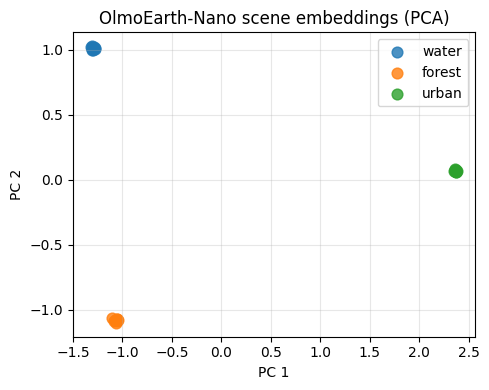

In [7]:
from sklearn.decomposition import PCA

pcs = PCA(n_components=2).fit_transform(scene_emb)
fig, ax = plt.subplots(figsize=(5, 4))
for i, cls in enumerate(CLASSES):
    m = labels == i
    ax.scatter(pcs[m, 0], pcs[m, 1], label=cls, s=60, alpha=0.8)
ax.legend()
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("OlmoEarth-Nano scene embeddings (PCA)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Application 1 — 5-NN scene classification

This is the cheapest evaluation Ai2 themselves run (k-NN on frozen embeddings, no fine-tuning). With 30 chips split 60/40 it should be trivial on this synthetic task; the point is the **protocol**.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X_tr, X_te, y_tr, y_te = train_test_split(
    scene_emb, labels, test_size=0.4, random_state=0, stratify=labels
)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)
y_pred = knn.predict(X_te)

print(f"n_train = {len(X_tr)}   n_test = {len(X_te)}")
print(f"5-NN accuracy: {accuracy_score(y_te, y_pred):.3f}")
print()
print("confusion matrix (rows=true, cols=pred):")
print("           " + " ".join(f"{c:>7}" for c in CLASSES))
cm = confusion_matrix(y_te, y_pred, labels=list(range(len(CLASSES))))
for i, c in enumerate(CLASSES):
    print(f"  {c:>8}   " + " ".join(f"{v:>7d}" for v in cm[i]))

n_train = 18   n_test = 12
5-NN accuracy: 1.000

confusion matrix (rows=true, cols=pred):
             water  forest   urban
     water         4       0       0
    forest         0       4       0
     urban         0       0       4


## Application 2 — per-patch token norms

OlmoEarth doesn't just produce a single scene embedding; it produces tokens for every `(patch, band-set, timestep)` triple. A quick sanity check: take the L2 norm of each patch token (averaged across band-sets) and plot it as an 8×8 heatmap over the chip.

On synthetic chips this should be roughly uniform (no spatial structure). On a real Sentinel-2 chip the same code would surface things like field boundaries and roads — exactly the signal you'd want for downstream segmentation.

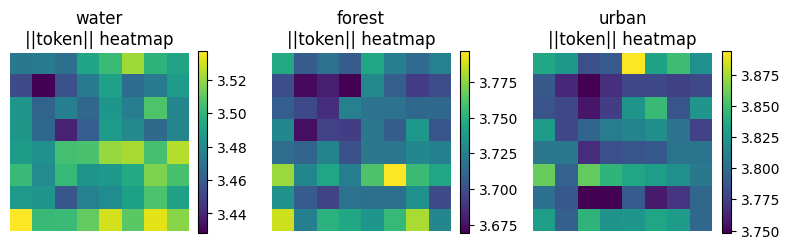

per-class mean token norm:
     water: 3.490
    forest: 3.717
     urban: 3.801


In [9]:
# patch_tokens: (N, 8, 8, T=1, num_band_sets=3, D=128)
token_norms = patch_tokens.float().norm(dim=-1).mean(dim=(3, 4)).cpu().numpy()  # (N, 8, 8)

fig, axes = plt.subplots(1, 3, figsize=(8, 2.8))
for ax, cls in zip(axes, CLASSES):
    idx = int(np.where(labels == CLASSES.index(cls))[0][0])
    im = ax.imshow(token_norms[idx], cmap="viridis")
    ax.set_title(f"{cls}\n||token|| heatmap")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print("per-class mean token norm:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:>8}: {token_norms[labels == i].mean():.3f}")

## Honest caveats

- **Synthetic chips have no spatial structure.** They are spatially i.i.d. Gaussian noise around a mean reflectance vector. A real evaluation needs real Sentinel-2 from the Microsoft Planetary Computer or AWS Open Data, with real labels (ESA WorldCover, EuroSAT, BigEarthNet).
- **Nano is the smallest model.** Use `ModelID.OLMOEARTH_V1_TINY`, `OLMOEARTH_V1_BASE`, or `OLMOEARTH_V1_LARGE` for actual downstream work. The API is identical; only the parameter count and embedding dim change.
- **Single timestep, single modality.** OlmoEarth shines with multi-month Sentinel-2 + Sentinel-1 + Landsat stacks. This demo is the simplest possible call.
- **License.** The OlmoEarth weights ship under the [OlmoEarth Artifact License](https://allenai.org/olmoearth); check it before you build a product on top.

## References

- Ai2 blog: [OlmoEarth v1.1: A more efficient family of Earth observation models](https://huggingface.co/blog/allenai/olmoearth-v1-1) (May 19, 2026)
- Ai2 blog: [OlmoEarth: A new state-of-the-art Earth observation foundation model family](https://allenai.org/blog/olmoearth-models) (Nov 2025)
- Technical report: [OlmoEarth: Stable Latent Image Modeling for Multimodal Earth Observation](https://arxiv.org/pdf/2511.13655)
- Code: [allenai/olmoearth_pretrain](https://github.com/allenai/olmoearth_pretrain), [allenai/rslearn](https://github.com/allenai/rslearn), [allenai/olmoearth_projects](https://github.com/allenai/olmoearth_projects)
- Platform: [olmoearth.allenai.org](https://olmoearth.allenai.org/)